# Introduzione a PyTorch

PyTorch fornisce diversi moduli, di cui ``torch.nn`` è quello base per  la creazione dei modelli neurali, mentre i dati sono gestiti tramite ``torch.utils.data.DataSet`` che si occupa di caricare i dati dalle sorgenti e creare i tensori e ``torch.utils.data.DataLoader`` che si occupa di creare i batch e caricarli sul device selezionato per l'addestramento.
Esitono poi le librerie ``torchvision``, ``torchtext`` e ``torchaudio`` che forniscono data set specifici e funzioni di gestione per i tre domini di riferimento.

In [1]:
# Importiamo tutte le librerire necessarie
import torch
from torch import nn
from torch.utils.data import random_split
from torchvision import datasets
from torchvision.transforms import v2
import os
import matplotlib.pyplot as plt
from torchsummary import summary
from torchnn import *

In [ ]:
# root dei percorsi
root = "/home/pirrone/src"
os.makedirs(root, exist_ok=True)

# percorso dei dati
data_path = os.path.join(root,'data')

# lo creiamo la prima volta
if not os.path.exists(data_path):
    os.mkdir(data_path)

# Analogamente per il percorso dei modelli
model_path = os.path.join(root,'models')

if not os.path.exists(model_path):
    os.mkdir(model_path)


In [2]:
# Acquisiamo il device su cui effettueremo il training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cpu device


Useremo il database ``FashionMNIST``per il nostro esempio: si tratta di 70000 immagini di dimensione 28x28, a livelli di grigio, che ritraggono capi di abbigliamento e sono associate a delle etichette testuali ch riportano il tipo di capo.

Abbiamo a che fare quindi con un problema di classificazione multiclasse di immagini che affronteremo con una rete neurale convoluizonale.

Il data set è suddiviso in un training set da 60000 immagini e un test set da 10000 immagini. Eseguiremo il download direttamente tramite ``torch`` che genererà un ``DataSet``.

In [13]:
# Definiamo un set di trasformazioni per implementare la data augmentation
transforms = v2.Compose([
    v2.RandomAffine(degrees=(-20, 20), translate=(0.15, 0.15)), # rotazione random di un angolo tra -20° e +20°
    v2.RandomHorizontalFlip(p=0.5),                             # flip orizzontale con probabilità del 50%
    v2.ToImage(),                                               # Composizione di trasformazioni
    v2.ToDtype(torch.float32, scale=True)                       # equivalente a ToTensor e raccomandata dalla documentaizone
])

tensors = v2.Compose([
    v2.ToImage(),                                               # Composizione di trasformazioni
    v2.ToDtype(torch.float32, scale=True)])                     # equivalente a ToTensor e raccomandata dalla documentaizone

In [ ]:
# flag per forzare il download del data set solo la prima volta
download = not os.path.exists(os.path.join(data_path,'FashionMNIST'))

# Download del training set da un open data set.
training_data = datasets.FashionMNIST(
    root=data_path,
    train=True,         # esegue il download dalla cartella/archivio dei dati di train del data set originale
    download=download,
    transform=transforms,
)

# Download del training set da un open test set.
test = datasets.FashionMNIST(
    root=data_path,
    train=False,
    download=download,
    transform=tensors
)

# eseguiamo lo split 90% - 10% dei dati di train per creare il validation set
test_size = int(0.9 * len(test))
val_size = int(0.1 * len(test))

# spostiamo i dati sulla GPU prima dello split così gli indici dei due split fanno riferimento già a tensori sul device
training_data.data.to(device)
test.data.to(device)

test_data, val_data = random_split(test, [test_size, val_size])

print(f"Campioni nel training set: {len(training_data)}\
        \nCampioni nel validation set: {len(val_data)}\
        \nCampioni nel test set: {len(test_data)}")

Campioni nel training set: 60000        
Campioni nel validation set: 1000        
Campioni nel test set: 9000


### Tensori

Nel codice precedente abbiamo visto che la trasformazione usata nella creazione dei data set è quella tipica, ovvero la chiamata di ``torchvision.ToTensor()`` che converte un'immagine di dimensioni HxWxC in un tensore di dimensioni CxHxW. Le trasformazioni possono essere anche definite dall'utente attraverso funzioni lambda.

I tensori in Pytorch sono implementati in maniera molto simile agli array in ``numpy``: essi hanno diversi tipi dei dati, infatti la classe base ``torch.Tensor`` è il default che ha un ``dtype=torch.float32`` ed è un alias per ``torch.FloatTensor``.
Pytorch usa i tensori per implementare tutta l'algebra lineare, le operazioni di campionamento, e quelle che guidano la propagazione dei gradienti durante l'addestramento.

I tensori possono essere creati da specifiche operazioni che danno come risultato un tensore, come ``torch.randint()`` che vedremo tra poco e che genera un tensore di numeri interi casuali di data dimensione, oppure esplicitamente con ``torch.tensor()`` che crea un tensore da una struttura di tipo array.

### Dataset
Un ``Dataset`` è in genere implementato come una ``map`` Python, quindi con accesso a indice, ma può essere anche creato come sottoclasse di ``IterableDataset`` come un iteratore.

Diamo un'occhiata al nostro data set, ricordandoci che è implementato con accesso ad indice.

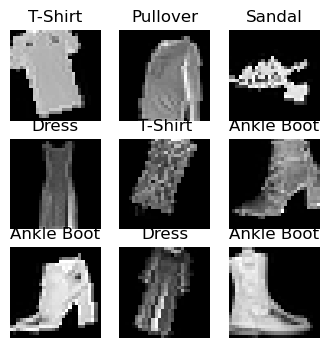

In [16]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(4, 4))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    # Genero un tensore casuale composto da un solo elemento nel range della lunghezza del data set
    # e lo converto in numero usando il metodo Tensor.item()
    sample_idx = int(torch.randint(len(training_data), size=(1,)).item())
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [12]:
# Creiamo i data loaders che saranno gli iterabili che generano i batch di
# addestramento e/o test
train_dataloader, val_dataloader, test_dataloader = make_dataloaders(training_data,
                                                                     val_data,
                                                                     test_data)

Shape e tipo dei campioni: torch.Size([64, 1, 28, 28]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


In [8]:
#  Creiamo il modello
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.deep_conv_stack = nn.Sequential(
            nn.Conv2d(1, 64, 3),        # Shape: (N, 1, 28, 28)   --> (N, 64, 26, 26) a causa del kernel 3x3
            nn.ReLU(),
            nn.Conv2d(64, 128, 3),      # Shape: (N, 64, 26, 26)  --> (N, 128, 24, 24)
            nn.ReLU(),
            nn.Conv2d(128, 256, 3),     # Shape: (N, 128, 24, 24) --> (N, 256, 22, 22)
            nn.ReLU(),
            nn.Conv2d(256, 64, 3),      # Shape: (N, 256, 22, 22) --> (N, 64, 20, 20)
            nn.ReLU(),
            nn.AvgPool2d(2),            # Shape: (N, 64, 20, 20)  --> (N, 64, 10, 10) a causa della divisione per due
            nn.Conv2d(64, 32, 3),       # Shape: (N, 64, 10, 10)  --> (N, 32, 8, 8)
            nn.ReLU(),
            nn.AvgPool2d(2),            # Shape: (N, 32, 8, 8)    --> (N, 32, 4, 4)
            nn.Flatten(1,-1),           # Shape: (N, 32, 4, 4)    --> (N, 512) il flatten moltiplica tutte le dimensioni tra loro
            nn.Linear(512, 10)          # Shape: (N, 512)         --> (N, 10) strato denso di calcolo dei logits
        )

    def forward(self, x):
        # Calcolo della rete in avanti
        logits = self.deep_conv_stack(x)                # parte profonda della rete che estrae i logits
        pred_probab = nn.LogSoftmax(dim=1)(logits)      # uscita esplicita con log-softmax per la predizione delle etichette
        return pred_probab

# Il metodo to() sposta il modello sul device selezionato
model = NeuralNetwork().to(device)

# Riportiamo il sommario del modello con torchinfo.summary()
summary(model, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
              ReLU-2           [-1, 64, 26, 26]               0
            Conv2d-3          [-1, 128, 24, 24]          73,856
              ReLU-4          [-1, 128, 24, 24]               0
            Conv2d-5          [-1, 256, 22, 22]         295,168
              ReLU-6          [-1, 256, 22, 22]               0
            Conv2d-7           [-1, 64, 20, 20]         147,520
              ReLU-8           [-1, 64, 20, 20]               0
         AvgPool2d-9           [-1, 64, 10, 10]               0
           Conv2d-10             [-1, 32, 8, 8]          18,464
             ReLU-11             [-1, 32, 8, 8]               0
        AvgPool2d-12             [-1, 32, 4, 4]               0
          Flatten-13                  [-1, 512]               0
           Linear-14                   

In [9]:
loss_fn = nn.NLLLoss()               # Negative log-likelihood

optimizer = torch.optim.SGD(
                            model.parameters(),
                            lr=config['learning_rate'],
                            momentum=config['momentum'],
                            nesterov=config['nesterov']
                            )

In [10]:
# Creiamo la callback di early stopping con i oarametri di deafault della configurazione da passare al nostro metodo di addestramento
early_stopping = EarlyStopping()

# Routine di addestramento
train_loss, validation_loss, test_loss, accuracy, metrics = train_test(model,
                                                              optimizer,
                                                              device,
                                                              train_dataloader,
                                                              test_dataloader,
                                                              train_loss_fn=loss_fn,
                                                              test_loss_fn=loss_fn,
                                                              early_stopping=early_stopping,
                                                              val_dataloader=val_dataloader)

Epoch    1: 100%|██████████| 844/844 [00:11<00:00, 72.85it/s]


Train loss: 2.0908
Validation loss: 1.3823
Test loss: 1.3814 Accuracy:   0.49
 Metrics:

precision_score:   0.51  recall_score:   0.49  f1_score:   0.46  


Epoch    2: 100%|██████████| 844/844 [00:11<00:00, 71.66it/s]


Train loss: 1.1697
Validation loss: 1.0120
Test loss: 1.0077 Accuracy:   0.63
 Metrics:

precision_score:   0.63  recall_score:   0.63  f1_score:   0.61  


Epoch    3: 100%|██████████| 844/844 [00:12<00:00, 68.51it/s]


...

Train loss: 0.6300
Validation loss: 0.6494
Test loss: 0.6584 Accuracy:   0.75
 Metrics:

precision_score:   0.76  recall_score:   0.75  f1_score:   0.75  


Epoch   19: 100%|██████████| 844/844 [00:12<00:00, 67.90it/s]


Train loss: 0.6234
Validation loss: 0.6263
Test loss: 0.6492 Accuracy:   0.77
 Metrics:

precision_score:   0.76  recall_score:   0.77  f1_score:   0.76  


Epoch   20: 100%|██████████| 844/844 [00:12<00:00, 67.41it/s]


Train loss: 0.6213
Validation loss: 0.6458
Test loss: 0.6477 Accuracy:   0.76
 Metrics:

precision_score:   0.77  recall_score:   0.76  f1_score:   0.76  


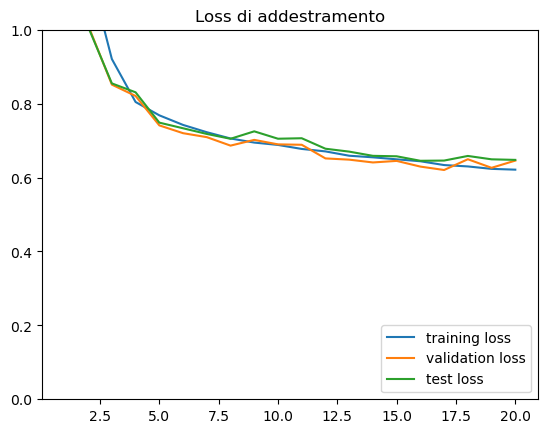

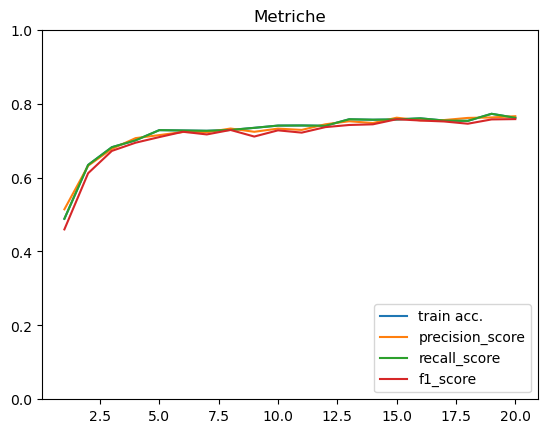

In [11]:
displayLosses(train_loss, test_loss, validation_loss)

displayMetrics(accuracy, metrics)

## Salvataggio e caricamento del modello

Come già sappiamo, quando l'addestramento si interrompe a causa di un early stoppping ovvero perché è necessario frazionarlo per gestire le risorse limitate della GPU, ma anche semplicemente alla sua fine naturale il modello viene salvato per poterlo successivamente ricaricare a fini di fine tuning o di predizione. Si usa chiamare questa azione _model checkpoint_.

Anche questa operazione andrà codificata creando delle semplici API basate sulle primitive di ``Torch`` denominate ``torch.save()`` e ``torch.load()`` le quali salvano un qualunque ``dict`` in forma serializzata utilizzando il modulo nativo ``Python`` denominato ``pickle``.

Creeremo due semplici wrapper per le operazioni di salvataggio e caricamento del model checkpoint.

In [12]:
# utilizziamo le API per salvare e ricaricare il modello
save_model(model,
           optimizer,
           len(train_loss),
           train_loss,
           validation_loss,
           test_loss,
           accuracy,
           metrics,
           os.path.join(model_path,'first_nn_torch.pth'))

mod = NeuralNetwork()
opt = torch.optim.SGD(mod.parameters(),
                            lr=config['learning_rate'],
                            momentum=config['momentum'],
                            nesterov=config['nesterov']
                            )

(mod, opt, model_checkpoint) = load_model(os.path.join(model_path,'first_nn_torch.pth'),
                                          mod,
                                          opt,
                                          device=device)

In [13]:
# Vogliamo riaddestrare il modello dopo l'early stopping, per cui
# inseriamo uno scheduler che faccia decrescere il learning rate ad ogni epoca
# come ulteriore regolarizzazione
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)

# Usiamo lo scheduler al posto dell'ottimizzatore nell'addestramento
tr_loss, val_loss, t_loss, new_accuracy, new_metrics = train_test(mod,
                                                                  opt, 
                                                                  device, 
                                                                  train_dataloader, 
                                                                  test_dataloader,
                                                                  epochs=5,
                                                                  train_loss_fn=loss_fn,
                                                                  test_loss_fn=loss_fn,
                                                                  scheduler=scheduler, 
                                                                  val_dataloader=val_dataloader)

Epoch    1: 100%|██████████| 844/844 [00:12<00:00, 68.14it/s]


Train loss: 0.6144
Validation loss: 0.6275
Test loss: 0.6479 Accuracy:   0.76
 Metrics:

precision_score:   0.78  recall_score:   0.76  f1_score:   0.76  


Epoch    2: 100%|██████████| 844/844 [00:12<00:00, 67.54it/s]


Train loss: 0.6042
Validation loss: 0.6124
Test loss: 0.6243 Accuracy:   0.77
 Metrics:

precision_score:   0.77  recall_score:   0.77  f1_score:   0.77  


Epoch    3: 100%|██████████| 844/844 [00:12<00:00, 66.35it/s]


Train loss: 0.5940
Validation loss: 0.6085
Test loss: 0.6136 Accuracy:   0.77
 Metrics:

precision_score:   0.77  recall_score:   0.77  f1_score:   0.76  


Epoch    4: 100%|██████████| 844/844 [00:12<00:00, 68.01it/s]


Train loss: 0.5867
Validation loss: 0.6210
Test loss: 0.6263 Accuracy:   0.77
 Metrics:

precision_score:   0.77  recall_score:   0.77  f1_score:   0.77  


Epoch    5: 100%|██████████| 844/844 [00:12<00:00, 67.82it/s]


Train loss: 0.5815
Validation loss: 0.5982
Test loss: 0.6055 Accuracy:   0.78
 Metrics:

precision_score:   0.78  recall_score:   0.78  f1_score:   0.78  


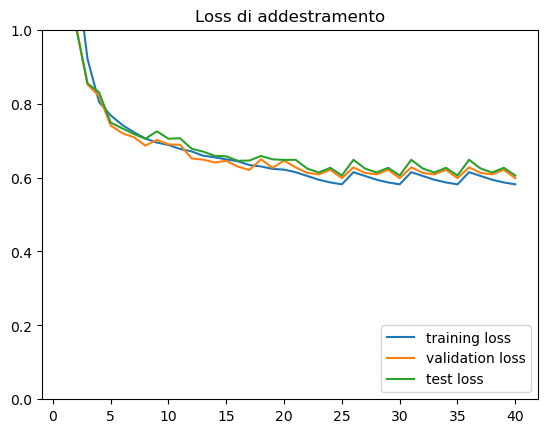

ValueError: x and y must have same first dimension, but have shapes (40,) and (35,)

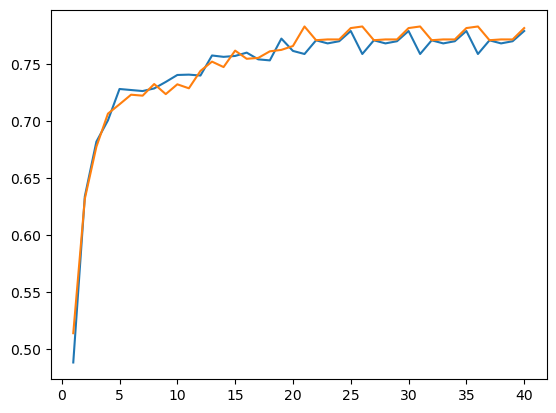

In [22]:
# concateniamo le liste delle loss e delle metriche relative ai due addestramenti e facciamo il plot
model_checkpoint['accuracy'].extend(new_accuracy)
model_checkpoint['training_loss'].extend(tr_loss)
model_checkpoint['validation_loss'].extend(val_loss)
model_checkpoint['test_loss'].extend(t_loss)

extended_metrics = {}
for label, metric in new_metrics.items():
    model_checkpoint[label].extend(metric)
    extended_metrics[label] = model_checkpoint[label]

displayLosses(model_checkpoint['training_loss'], model_checkpoint['test_loss'], model_checkpoint['validation_loss'])
displayMetrics(model_checkpoint['accuracy'], extended_metrics)



In [24]:
len(new_metrics['f1_score'])

5